# 1. Import Module
         
    

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


# 2. Load data

In [2]:
file = "C:/Users/USER-PC/QSAR_Code/Skin Irritation/dataset/Skin_irritation_balanced_st.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[11:29:21] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[11:29:21] ERROR: Could not sanitize molecule ending on line 20825
[11:29:21] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[11:29:21] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 21 22 23
[11:29:21] ERROR: Could not sanitize molecule ending on line 34178
[11:29:21] ERROR: Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 21 22 23
[11:29:21] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
[11:29:21] ERROR: Could not sanitize molecule ending on line 43069
[11:29:21] ERROR: Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
Failed to patch pandas - unable to change molecule rendering


(551, 18)
(551, 18)


Index(['id_input', 'InChIKey', 'substance_name', 'casrn', 'Molecular weight',
       'guideline', 'species', 'type_of_coverage', 'max_duration(hrs)',
       'vehicle', 'edema/ erythema score', 'max_score', 'reversibility',
       'Outcome', 'StandardizerResult', 'ID', 'SMILES', 'Mol'],
      dtype='object')

In [3]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

In [4]:
moldf.head(1)

,id_input,InChIKey,substance_name,casrn,Molecular weight,guideline,species,type_of_coverage,max_duration(hrs),vehicle,edema/ erythema score,max_score,reversibility,Outcome,StandardizerResult,ID,SMILES,Mol
0,951,ACVNYUMGXUDACR-UHFFFAOYSA-N,-,65405-84-7,208.3397674560547,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,unchanged (no vehicle),2.33333333333333,4.0,0.0,1,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CC1=CCCC(C)(C)C1C(C)CCC=O,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...


In [5]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf['RowID'] = moldf.index
moldf.head(100)

,id_input,InChIKey,substance_name,casrn,Molecular weight,guideline,species,type_of_coverage,max_duration(hrs),vehicle,edema/ erythema score,max_score,reversibility,Outcome,StandardizerResult,ID,SMILES,Mol,RowID
553,"2545, 4714",QIQXTHQIDYTFRH-UHFFFAOYSA-N,2-methylheptadecanoic acid,30399-84-9,284.47723388671875,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,14.0,unchanged (no vehicle),0.6,4.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CCCCCCCCCCCCCCCCCC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x00000200E81...,553
378,1167,NPRQLWMILWHEDI-UHFFFAOYSA-N,-,268567-32-4,328.4282531738281,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,unchanged (no vehicle),0.0,4.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CC(C)COP(=S)(OCC(C)C)SCC(C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,378
377,2961,KBZFDRWPMZESDI-UHFFFAOYSA-N,"5-aminobenzene-1,3-dicarboxylic acid",99-31-0,181.14547729492188,EU Method B.4 (Acute Toxicity: Dermal Irritati...,rabbit,semiocclusive,4.0,unchanged (no vehicle),0.0,0.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,Nc1cc(C(=O)O)cc(C(=O)O)c1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,377
376,1871,GQBVHGLNSHPKPG-UHFFFAOYSA-N,1-[(2-tert-butylcyclohexyl)oxy]butan-2-ol,139504-68-0,228.3709259033203,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,unchanged (no vehicle),1.0,4.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CCC(O)COC1CCCCC1C(C)(C)C,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,376
375,4851,DFPAKSUCGFBDDF-UHFFFAOYSA-N,pyridine-3-carboxamide,98-92-0,122.12464141845703,EU Method B.4 (Acute Toxicity: Dermal Irritati...,rabbit,semiocclusive,4.0,water,0.0,0.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,NC(=O)c1cccnc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,1633,XYBGJUIUCFENGS-UHFFFAOYSA-N,-,866607-35-4,612.6624145507812,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,water,0.0,4.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CC(=O)OCC1OC(c2ccc(C)c(Cc3ccc(-c4ccc(F)cc4)s3)...,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,283
282,2041,CNGYZEMWVAWWOB-UHFFFAOYSA-N,"2,2'-ethene-1,2-diylbis[5-({4-anilino-6-[bis(2...",4404-43-7,916.9817504882812,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,occlusive,4.0,water,0.0,4.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,O=S(=O)(O)c1cc(Nc2nc(Nc3ccccc3)nc(N(CCO)CCO)n2...,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,282
281,3453,BIJVAEAOBFTYKO-UHFFFAOYSA-N,"N-(4-chloro-2,5-dimethoxyphenyl)-2-[(E)-2-[2,5...",12225-18-2,591.0325927734375,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,water,0.0,4.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,COc1cc(NC(=O)/C(=N\Nc2cc(OC)c(S(=O)(=O)Nc3cccc...,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,281
280,2981,JHDBOXMMELKDCY-FMQUCBEESA-N,5-oxo-4-[(E)-2-{4-[2-(sulfooxy)ethanesulfonyl]...,10149-98-1,576.5342407226562,other: OECD Guideline 402 (Acute Dermal Toxicity),rat,semiocclusive,24.0,unchanged (no vehicle),0.0,4.0,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,O=C(O)c1[nH]n(-c2ccc(S(=O)(=O)O)cc2)c(=O)c1/N=...,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,280


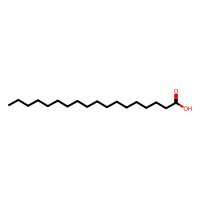

CCCCCCCCCCCCCCCCCC(=O)O


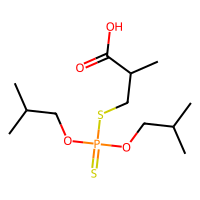

CC(C)COP(=S)(OCC(C)C)SCC(C)C(=O)O


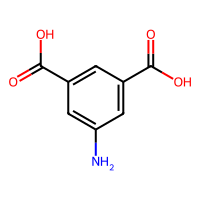

Nc1cc(C(=O)O)cc(C(=O)O)c1


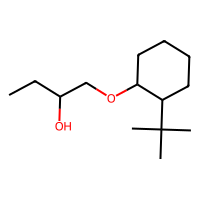

CCC(O)COC1CCCCC1C(C)(C)C


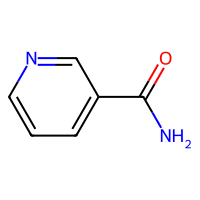

NC(=O)c1cccnc1


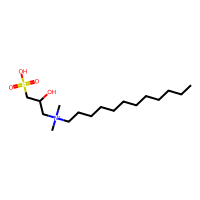

CCCCCCCCCCCC[N+](C)(C)CC(O)CS(=O)(=O)O


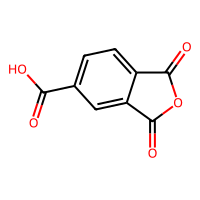

O=C(O)c1ccc2c(c1)C(=O)OC2=O


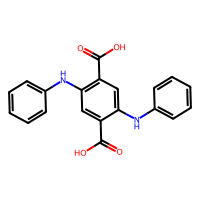

O=C(O)c1cc(Nc2ccccc2)c(C(=O)O)cc1Nc1ccccc1


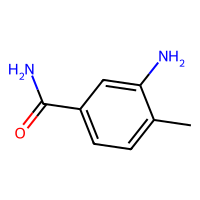

Cc1ccc(C(N)=O)cc1N


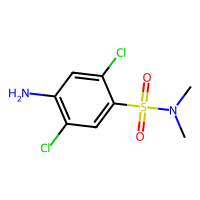

CN(C)S(=O)(=O)c1cc(Cl)c(N)cc1Cl


In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(moldf, num_mols):
    for _, row in moldf.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 10)


In [7]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mordred import Calculator, descriptors
from fancyimpute import KNN


(CVXPY) Sep 13 11:29:54 AM: Encountered unexpected exception importing solver CVXOPT:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 13 11:29:54 AM: Encountered unexpected exception importing solver GLPK:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 13 11:29:54 AM: Encountered unexpected exception importing solver GLPK_MI:
ImportError('DLL load failed while importing base: The specified module could not be found.')


## 3. Morgan, MACCsKeys, Modred

In [8]:
# Morgan fingerprints
nBits = 1024
radius = 2
useFeatures = False
moldf['Morgan_Descriptors'] = moldf['Mol'].apply(lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, nBits=nBits, radius=radius, useFeatures=useFeatures))

# MACCS keys
moldf['MACCS_Descriptors'] = moldf['Mol'].apply(lambda mol: MACCSkeys.GenMACCSKeys(mol))



In [9]:
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from mordred import Calculator, descriptors

# create descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=True)
df = calc.pandas(moldf['Mol'])

 13%|█▎        | 72/551 [00:03<00:12, 37.12it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 16%|█▌        | 86/551 [00:04<00:12, 36.40it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 18%|█▊        | 97/551 [00:04<00:11, 38.93it/s]

...

 37%|███▋      | 206/551 [00:05<00:03, 102.33it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 51%|█████     | 280/551 [00:06<00:02, 102.08it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 551/551 [00:08<00:00, 61.34it/s] 


In [10]:
from fancyimpute import KNN
import pandas as pd
import numpy as np

df_numeric = df.select_dtypes(include=[float])  
df_filled = pd.DataFrame(KNN(k=3).fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)


Imputing row 1/551 with 0 missing, elapsed time: 0.439
Imputing row 101/551 with 0 missing, elapsed time: 0.440
Imputing row 201/551 with 0 missing, elapsed time: 0.440
Imputing row 301/551 with 0 missing, elapsed time: 0.440
Imputing row 401/551 with 0 missing, elapsed time: 0.441
Imputing row 501/551 with 0 missing, elapsed time: 0.441


In [11]:
X = np.array(df_filled)
scaler = StandardScaler()
x=  scaler.fit_transform(X)
moldf['Modred_Descriptor'] = x.tolist()

In [12]:
print(x.shape)

(551, 839)


In [13]:
moldf

,id_input,InChIKey,substance_name,casrn,Molecular weight,guideline,species,type_of_coverage,max_duration(hrs),vehicle,...,reversibility,Outcome,StandardizerResult,ID,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
553,"2545, 4714",QIQXTHQIDYTFRH-UHFFFAOYSA-N,2-methylheptadecanoic acid,30399-84-9,284.47723388671875,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,14.0,unchanged (no vehicle),...,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CCCCCCCCCCCCCCCCCC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x00000200E81...,553,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.34459422568696013, -1.1719378966146925, -1...."
378,1167,NPRQLWMILWHEDI-UHFFFAOYSA-N,-,268567-32-4,328.4282531738281,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,unchanged (no vehicle),...,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CC(C)COP(=S)(OCC(C)C)SCC(C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,378,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.14241939919880642, 0.2705837490587057, 0.32..."
377,2961,KBZFDRWPMZESDI-UHFFFAOYSA-N,"5-aminobenzene-1,3-dicarboxylic acid",99-31-0,181.14547729492188,EU Method B.4 (Acute Toxicity: Dermal Irritati...,rabbit,semiocclusive,4.0,unchanged (no vehicle),...,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,Nc1cc(C(=O)O)cc(C(=O)O)c1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,377,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.34373094854706193, 0.47764311538706017, 0...."
376,1871,GQBVHGLNSHPKPG-UHFFFAOYSA-N,1-[(2-tert-butylcyclohexyl)oxy]butan-2-ol,139504-68-0,228.3709259033203,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,unchanged (no vehicle),...,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CCC(O)COC1CCCCC1C(C)(C)C,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,376,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.034815991593610096, 0.66803429799458, 0.73..."
375,4851,DFPAKSUCGFBDDF-UHFFFAOYSA-N,pyridine-3-carboxamide,98-92-0,122.12464141845703,EU Method B.4 (Acute Toxicity: Dermal Irritati...,rabbit,semiocclusive,4.0,water,...,0.0,0,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,NC(=O)c1cccnc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,375,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6411342357143425, -0.17913450655341068, -0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,2546,RZBBHEJLECUBJT-UHFFFAOYSA-N,2-methylheptyl 2-sulfanylacetate,25103-09-7,204.32960510253906,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,unchanged (no vehicle),...,0.0,1,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,CC(C)CCCCCOC(=O)CS,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,185,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.33546491193985767, -1.0152756893381816, -0..."
186,5328,RZHGQUVEZKATLV-UHFFFAOYSA-N,unnamed [1639345-42-8],1639345-42-8,145.25009155273438,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,unchanged (no vehicle),...,0.0,1,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,C[Si](C)(F)CCCC#N,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,186,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7823437450684362, -0.5603393286181595, -0...."
187,1825,SBJCUZQNHOLYMD-UHFFFAOYSA-N,"1,5-diisocyanatonaphthalene",3173-72-6,210.18824768066406,OECD Guideline 404 (Acute Dermal Irritation / ...,rabbit,semiocclusive,4.0,other: moistened with corn oil,...,0.0,1,Remove Explicit Hydrogens (ID: RemoveExplicitH...,,O=C=Nc1cccc2c(N=C=O)c

In [14]:
moldf.keys()

Index(['id_input', 'InChIKey', 'substance_name', 'casrn', 'Molecular weight',
       'guideline', 'species', 'type_of_coverage', 'max_duration(hrs)',
       'vehicle', 'edema/ erythema score', 'max_score', 'reversibility',
       'Outcome', 'StandardizerResult', 'ID', 'SMILES', 'Mol', 'RowID',
       'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor'],
      dtype='object')

In [15]:
data = moldf.drop(columns=['id_input', 'InChIKey', 'substance_name', 'casrn', 'Molecular weight',
       'guideline', 'species', 'type_of_coverage', 'max_duration(hrs)',
       'vehicle', 'edema/ erythema score', 'max_score', 'reversibility','StandardizerResult', 'ID',])

In [16]:
data

,Outcome,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
553,0,CCCCCCCCCCCCCCCCCC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x00000200E81...,553,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.34459422568696013, -1.1719378966146925, -1...."
378,0,CC(C)COP(=S)(OCC(C)C)SCC(C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,378,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.14241939919880642, 0.2705837490587057, 0.32..."
377,0,Nc1cc(C(=O)O)cc(C(=O)O)c1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,377,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.34373094854706193, 0.47764311538706017, 0...."
376,0,CCC(O)COC1CCCCC1C(C)(C)C,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,376,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.034815991593610096, 0.66803429799458, 0.73..."
375,0,NC(=O)c1cccnc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,375,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6411342357143425, -0.17913450655341068, -0..."
...,...,...,...,...,...,...,...
185,1,CC(C)CCCCCOC(=O)CS,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,185,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.33546491193985767, -1.0152756893381816, -0..."
186,1,C[Si](C)(F)CCCC#N,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,186,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7823437450684362, -0.5603393286181595, -0...."
187,1,O=C=Nc1cccc2c(N=C=O)cccc12,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,187,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.08764942839496762, 0.9185308075190416, 0.98..."
181,1,NCC1C2CCC(C2)C1CN,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,181,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.38673224572252146, 1.2406845313019266, 0.7..."


In [17]:
data.keys()

Index(['Outcome', 'SMILES', 'Mol', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor'],
      dtype='object')

# 4. Split into Train and Test Data and Save into sdf file

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect



# Remove duplicate columns
data = data.loc[:, ~data.columns.duplicated()]

# Split the data into train and test sets
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Function to convert bit vectors to a list of integers
def bitvector_to_list(bitvector):
    if isinstance(bitvector, ExplicitBitVect):
        return list(map(int, bitvector.ToBitString()))
    else:
        return bitvector

# Convert bit vectors to lists before saving
def convert_bit_vectors(df):
    if 'Morgan_Descriptors' in df.columns:
        df['Morgan_Descriptors'] = df['Morgan_Descriptors'].apply(bitvector_to_list)
    if 'MACCS_Descriptors' in df.columns:
        df['MACCS_Descriptors'] = df['MACCS_Descriptors'].apply(bitvector_to_list)
    return df

# Convert bit vectors for train and test sets
train = convert_bit_vectors(train)
test = convert_bit_vectors(test)

# Function to save DataFrame to SDF
def save_to_sdf(df, filename):
    sdf_writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mol.SetProp("_Name", str(idx))
            for col in df.columns:
                if col != 'Mol' and col != 'SMILES':
                    mol.SetProp(col, str(row[col]))
            sdf_writer.write(mol)
    sdf_writer.close()


# Save the train and test sets to SDF files
save_to_sdf(train, 'C:/Users/USER-PC/QSAR_Code/Skin Irritation/dataset/train_set_skin_irritation_features.sdf')
save_to_sdf(test, 'C:/Users/USER-PC/QSAR_Code/Skin Irritation/dataset/tes_set_skin_irritation_features.sdf')

print("Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.")


Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.


In [19]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Skin Irritation/dataset/train_set_skin_irritation_features.sdf')
test_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Skin Irritation/dataset/tes_set_skin_irritation_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

print("Test DataFrame:")
print(test_df.head())


Train DataFrame:
  Outcome RowID                                 Morgan_Descriptors  \
0       1    57  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
1       1   205  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2       0   445  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0   379  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       1   110  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor  \
0  [-0.49982639580295857, -1.084992491992044, -1....   
1  [-0.4178613599092674, 0.13371156740649162, 0.1...   
2  [-0.4106617898955919, 0.4407202217479584, 0.50...   
3

In [20]:
train_df

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,1,57,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.49982639580295857, -1.084992491992044, -1....",CCOCCCOC(O)CC
1,1,205,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4178613599092674, 0.13371156740649162, 0.1...",CC(C)CC(C)OP(=S)(S)OC(C)C
2,0,445,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4106617898955919, 0.4407202217479584, 0.50...",CC(C)(C)c1ccc(C#N)cc1
3,0,379,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8141666872733075, -0.38901812751285475, -0...",C=Cn1ccnc1
4,1,110,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6957883439207186, 0.02886774372723733, 0.0...",CO[Si](OC)(OC)OC
...,...,...,...,...,...,...
435,0,307,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.932053295431659, 1.0888498501770312, 1.0071...",CC1=NN(c2ccccc2)C(=O)/C1=N/Nc1ccc(-c2ccc(N/N=C...
436,0,342,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.1499050992731923, 1.5597216913092669, 1.636...",Cc1ccc2[nH]c3cc4c(=O)c5cc(C)ccc5[nH]c4cc3c(=O)...
437,0,463,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.018564746005525636, 0.6431375900855004, 0.3...",CCCCCC1C(=O)CCC1CC(=O)OC
438,1,218,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.15969601443774015, 0.9458664461470997, 1.0...",C=CCOC(=O)C1C(C)CCCC1(C)C


In [21]:
train

,Outcome,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
57,1,CCOCCCOC(O)CC,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,57,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.49982639580295857, -1.084992491992044, -1...."
205,1,CC(C)CC(C)OP(=S)(S)OC(C)C,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,205,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4178613599092674, 0.13371156740649162, 0.1..."
445,0,CC(C)(C)c1ccc(C#N)cc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,445,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4106617898955919, 0.4407202217479584, 0.50..."
379,0,C=Cn1ccnc1,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,379,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8141666872733075, -0.38901812751285475, -0..."
110,1,CO[Si](OC)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x00000200E70...,110,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6957883439207186, 0.02886774372723733, 0.0..."
...,...,...,...,...,...,...,...
307,0,CC1=NN(c2ccccc2)C(=O)/C1=N/Nc1ccc(-c2ccc(N/N=C...,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,307,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.932053295431659, 1.0888498501770312, 1.0071..."
342,0,Cc1ccc2[nH]c3cc4c(=O)c5cc(C)ccc5[nH]c4cc3c(=O)...,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,342,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.1499050992731923, 1.5597216913092669, 1.636..."
463,0,CCCCCC1C(=O)CCC1CC(=O)OC,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,463,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.018564746005525636, 0.6431375900855004, 0.3..."
218,1,C=CCOC(=O)C1C(C)CCCC1(C)C,<rdkit.Chem.rdchem.Mol object at 0x00000200E71...,218,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.15969601443774015, 0.9458664461470997, 1.0..."
